In [18]:
import numpy as np
from tqdm import tqdm  # while loading images it shows progress Bar
import matplotlib.pyplot as plt
from PIL import Image
import os
from random import shuffle

In [19]:
TRAIN_DIR = '/content/train'
TEST_DIR = '/content/test'

In [20]:
IMG_SIZE = 120
MODEL_NAME = 'NIKEvsADIDAS'

In [21]:
def label_img(img):
    # Images are formatted as: ADIDAS_1, NIKE_3 ...
    word_label = img.split('_')[0]
    if word_label == 'NIKE': return [1,0] #one hot encoding
    elif word_label == 'ADIDAS': return [0,1] #one hot encoding

In [22]:
train_data = []
for img in tqdm(os.listdir(TRAIN_DIR)):
  label = label_img(img)
  path = os.path.join(TRAIN_DIR, img)
############################################################
# This part is different from sentdex's tutorial
# Chose to use PIL instead of cv2 for image pre-processing
############################################################
  if os.path.isdir(path):
    continue
  img = Image.open(path) #Read image syntax with PIL Library
  img = img.convert('L') #Grayscale conversion with PIL library
  img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS) #Resizing image syntax with PIL Library


  train_data.append([np.array(img), np.array(label)])
shuffle(train_data)

100%|██████████| 100/100 [00:00<00:00, 152.96it/s]


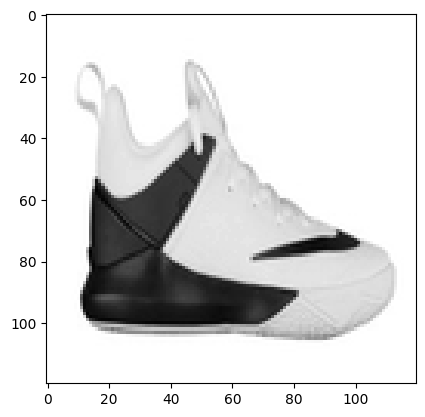

In [23]:
plt.imshow(train_data[3][0], cmap = 'gist_gray')
plt.show()

In [24]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [25]:
model = Sequential()

model.add(Conv2D(32,(5,5), activation='relu', input_shape=(120,120,1)))
model.add(Conv2D(32,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(5,5), activation='relu'))
model.add(Conv2D(64,(5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
X = np.array([i[0] for i in train_data]).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
Y = np.array([i[1] for i in train_data])

model.fit(X,Y,epochs=10)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4000 - loss: 420.7799
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5700 - loss: 6.1218
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6400 - loss: 0.6719
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7200 - loss: 0.5906
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.7000 - loss: 3.8573
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5000 - loss: 0.6931
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.5200 - loss: 0.6930
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5200 - loss: 0.6927
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.5200 - loss: 0.6926
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5400 - loss: 0.6924


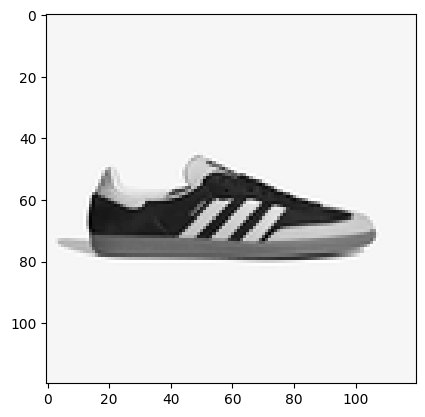

In [27]:
#PTL
img = Image.open('/content/adidas.webp')
img = img.convert('L')
img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

plt.imshow(np.array(img), cmap = 'gist_gray')
plt.show()

In [28]:
model.predict(np.array(img).reshape(-1, IMG_SIZE, IMG_SIZE, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


array([[0.5102763 , 0.48972368]], dtype=float32)